### Plot by Water Year (WY) Using a Function to clean this up

Notebook contents 
* All data downloaded from Synoptic Weather API, + Heen SNOTEL

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib 

In [2]:
pwd

'/home/cassie/python/repos/snowdepth_teleconnections'

### Load Data 

#### Load CSV created in script `3_clean_snowdepth...`

In [3]:
# save the df dataframe to a csv file
# df.to_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_ppsa_tram_heen_2015_2026.csv')

# load the saved csv file back into a dataframe
df = pd.read_csv('/home/cassie/python/repos/snowdepth_teleconnections/snow_depth_ppsa_tram_heen_2015_2026.csv', index_col=0, parse_dates=True)
df.head()

,heen,ppsa,tram,heen_smooth,ppsa_smooth,tram_smooth
datetime,,,,,,
2014-01-09 15:30:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-09 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-09 16:30:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-09 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-09 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN


### Compute Day of Water Year, Water Year, etc.

In [4]:
# Minimal time prep needed for smoothing (no WY plotting fields here).
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
else:
    df['datetime'] = pd.to_datetime(df.index)

# Standardize Powder Patch naming to 4-char station code.
if 'ppsa' not in df.columns and 'powderpatch' in df.columns:
    df = df.rename(columns={'powderpatch': 'ppsa'})
elif 'ppsa' not in df.columns:
    raise ValueError("Expected 'ppsa' or 'powderpatch' column in df.")

# Remove legacy pp_* smooth columns if present to avoid naming confusion.
legacy_pp_cols = [c for c in df.columns if c.startswith('pp_smooth_')]
if legacy_pp_cols:
    df = df.drop(columns=legacy_pp_cols)

# Continuous time axis for LOWESS input
first_date = df['datetime'].min()
df['day_since_first_wy'] = (df['datetime'] - first_date).dt.days

df[['datetime', 'day_since_first_wy', 'ppsa']].head()
df.head()

,heen,ppsa,tram,heen_smooth,ppsa_smooth,tram_smooth,datetime,day_since_first_wy
datetime,,,,,,,,
2014-01-09 15:30:00,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-09 15:30:00,0
2014-01-09 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-09 16:00:00,0
2014-01-09 16:30:00,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-09 16:30:00,0
2014-01-09 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-09 17:00:00,0
2014-01-09 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,2014-01-09 17:30:00,0


#### LOWESS Smoothing - moving it back here 

In [5]:
# import LOWESS function
from statsmodels.nonparametric.smoothers_lowess import lowess

# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df['ppsa_smooth_001'] = lowess(
    endog=df['ppsa'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df['ppsa_smooth_002'] = lowess(
    endog=df['ppsa'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df['ppsa_smooth_005'] = lowess(
    endog=df['ppsa'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df['heen_smooth_001'] = lowess(
    endog=df['heen'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df['heen_smooth_002'] = lowess(
    endog=df['heen'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df['heen_smooth_005'] = lowess(
    endog=df['heen'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df['tram_smooth_001'] = lowess(
    endog=df['tram'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df['tram_smooth_002'] = lowess(
    endog=df['tram'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df['tram_smooth_005'] = lowess(
    endog=df['tram'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

# Plot by Water Year (WY)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

## Plot Function #1: Grey out all fields, then highlight a single year 

In [7]:
def plot_snowdepth_by_wateryear(
    df,
    depth_col='ppsa_smooth_001',
    highlight_wy=None,
    other_years_style='grey',
    cmap_name='turbo',
    other_years_alpha=0.8,
    figsize=(14, 6),
    title=None,
):
    """
    Plot snow depth by water year with one highlighted year in black.

    The function computes plotting fields internally:
    - wy: water year (Sep-Aug)
    - wy_day: day of water year, starting at 1 on Sep 1

    Title behavior:
    - If title is provided, use it.
    - If title is None, infer station name from depth_col prefix:
      heen -> Heen Latinee SNOTEL
      ppsa -> Powder Patch
      tram -> Mount Roberts Tram
    """

    if depth_col not in df.columns:
        raise ValueError(f"Missing required column: {depth_col}")

    if title is None:
        station_code = depth_col.split('_')[0].lower()
        station_title_map = {
            'heen': 'Heen Latinee SNOTEL',
            'ppsa': 'Powder Patch',
            'tram': 'Mount Roberts Tram',
        }
        station_name = station_title_map.get(station_code, station_code.upper())
        title = f'Snow Depth Observations at {station_name}'

    # Build a local plotting dataframe so upstream notebook cells stay minimal.
    plot_df = df[[depth_col]].copy()

    if 'datetime' in df.columns:
        plot_df['dt'] = pd.to_datetime(df['datetime'])
    else:
        plot_df['dt'] = pd.to_datetime(df.index)

    plot_df = plot_df.dropna(subset=[depth_col, 'dt']).copy()
    if plot_df.empty:
        raise ValueError('No valid rows available for plotting after dropping NaNs.')

    # Compute water-year fields only inside this function.
    plot_df['wy'] = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year + 1,
        plot_df['dt'].dt.year,
    ).astype(int)

    wy_start_year = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year,
        plot_df['dt'].dt.year - 1,
    )
    wy_start = pd.to_datetime({'year': wy_start_year, 'month': 9, 'day': 1})
    wy_day = (plot_df['dt'].to_numpy() - wy_start.to_numpy()) / np.timedelta64(1, 'D')
    plot_df['wy_day'] = np.floor(wy_day).astype(int) + 1

    water_years = sorted(plot_df['wy'].unique())
    if not water_years:
        raise ValueError('No water years available to plot.')

    if highlight_wy is None:
        user_input = input(f"Enter a water year to highlight in black {water_years}: ")
        try:
            highlight_wy = int(user_input)
        except ValueError as exc:
            raise ValueError('Water year must be an integer.') from exc

    if highlight_wy not in water_years:
        raise ValueError(f"highlight_wy={highlight_wy} not found. Options: {water_years}")

    if other_years_style not in {'grey', 'colorscale'}:
        raise ValueError("other_years_style must be 'grey' or 'colorscale'.")

    fig, ax_in = plt.subplots(figsize=figsize)

    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))

    for year in water_years:
        if year == highlight_wy:
            continue

        year_data = plot_df[plot_df['wy'] == year]

        if other_years_style == 'grey':
            color = 'lightgrey'
        else:
            color = cmap(norm(year))

        ax_in.scatter(
            year_data['wy_day'],
            year_data[depth_col],
            color=color,
            alpha=other_years_alpha,
            s=10,
            edgecolors='none',
        )

    highlight_data = plot_df[plot_df['wy'] == highlight_wy]
    ax_in.plot(
        highlight_data['wy_day'],
        highlight_data[depth_col],
        color='black',
        linewidth=2.5,
        label=f'WY {highlight_wy}',
    )

    mean_by_day = (
        plot_df.groupby('wy_day')[depth_col]
        .mean()
        .sort_index()
    )
    ax_in.plot(
        mean_by_day.index,
        mean_by_day.values,
        color='black',
        linestyle='--',
        linewidth=2,
        label='mean',
    )

    # Month ticks for Sep-Aug on WY day axis (1-based).
    tick_dates = [pd.Timestamp(2001, m, 1) for m in range(9, 13)] + [
        pd.Timestamp(2002, m, 1) for m in range(1, 9)
    ]
    wy0 = pd.Timestamp(2001, 9, 1)
    tick_locs = [(d - wy0).days + 1 for d in tick_dates]
    tick_labels = [d.strftime('%b') for d in tick_dates]

    ax_in.set_xticks(tick_locs)
    ax_in.set_xticklabels(tick_labels)
    ax_in.set_xlabel('Day of Water Year (Sep-Aug)')

    ax_in.set_ylabel('snow depth (inches)')
    ax_in.set_ylim(-5, 205)

    ax_cm = ax_in.twinx()
    inch_to_cm = 2.54
    ymin, ymax = ax_in.get_ylim()
    ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
    ax_cm.set_ylabel('snow depth (cm)')

    ax_cm.yaxis.set_label_position('right')
    ax_cm.yaxis.tick_right()
    ax_in.yaxis.tick_left()
    ax_in.yaxis.set_label_position('left')
    ax_cm.grid(False)

    ax_in.set_title(title)
    ax_in.grid(True, alpha=0.3)
    
    
    if other_years_style == 'grey':
        legend_elements = [
            Line2D(
                [0], [0], 
                marker='o', 
                color='w', 
                markerfacecolor='lightgrey',
                markersize=7, 
                label='other years', 
                # alpha=other_years_alpha,
            ),
            Line2D([0], [0], color='black', lw=2.5, label=f'WY {highlight_wy}'),
            Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='mean'),
        ]
    else:
        # Build WY legend in chronological order, with highlighted WY at the right position.
        legend_elements = []
        for year in water_years:
            if year == highlight_wy:
                legend_elements.append(
                    Line2D([0], [0], color='black', lw=2.5, label=f'WY {year}')
                )
            else:
                legend_elements.append(
                    Line2D(
                        [0], [0],
                        marker='o',
                        color='w',
                        markerfacecolor=cmap(norm(year)),
                        markeredgecolor='none',
                        markersize=7,
                        label=f'WY {year}',
                        # alpha=other_years_alpha, # the legend markers should be fully opaque for visibility, even if the plotted points are transparent
                    )
                )

        # Keep Mean last as a summary/statistic line.
        legend_elements.append(
            Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Mean')
        )

    ax_in.legend(handles=legend_elements, loc='upper left', ncol=1)

    plt.tight_layout()
    plt.show()


## Example calls:
## 1) Prompt for highlighted WY, with all other years in grey
# plot_snowdepth_by_wateryear(df, depth_col='ppsa_smooth_001', other_years_style='grey')

## 2) Explicit highlight year, with all other years on a colorscale
## plot_snowdepth_by_wateryear(
##     df,
##     depth_col='ppsa_smooth_001',
##     highlight_wy=2025,
##     other_years_style='colorscale',
##     cmap_name='turbo',
## )
##
## 3) Override title manually (optional)
## plot_snowdepth_by_wateryear(
##     df,
##     depth_col='tram_smooth_001',
##     highlight_wy=2026,
##     title='Custom Title Here',
## )

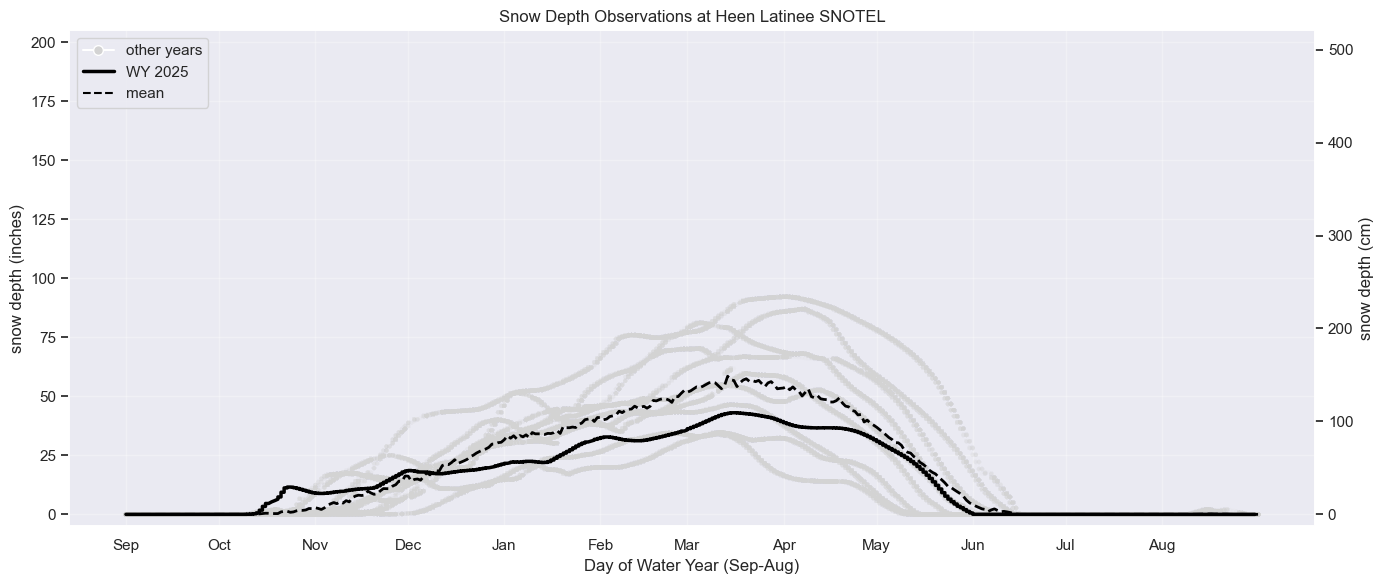

In [8]:
## Example calls:
## 1) No title passed -> auto title from depth_col station code
plot_snowdepth_by_wateryear(
    df,
    depth_col='heen_smooth_005',
    highlight_wy=2025,
    other_years_style='grey',
    other_years_alpha=0.1,
)

## 2) Explicit highlight year, with all other years on a colorscale
# plot_snowdepth_by_wateryear(
#     df,
#     depth_col='ppsa_smooth_001',
#     highlight_wy=2025,
#     other_years_style='colorscale',
#     cmap_name='turbo',
#     other_years_alpha=0.8,
# )

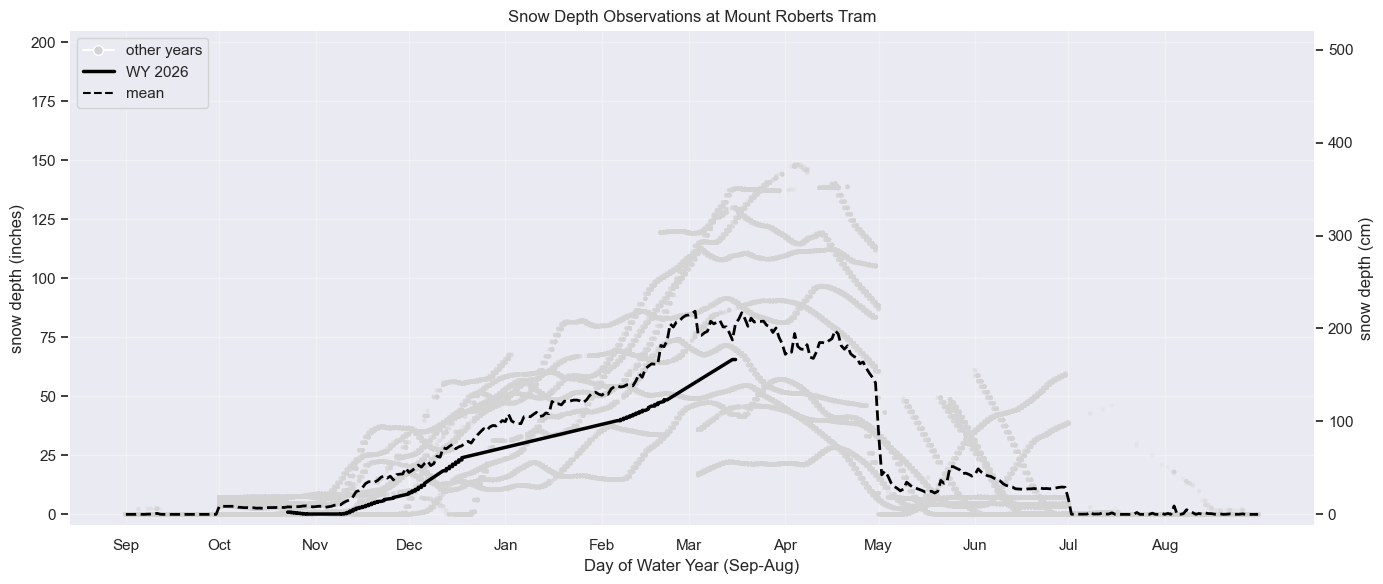

In [9]:
## Example calls:
## 1) No title passed -> auto title from depth_col station code
plot_snowdepth_by_wateryear(df, depth_col='tram_smooth_005', highlight_wy=2026, other_years_style='grey', other_years_alpha=0.2)

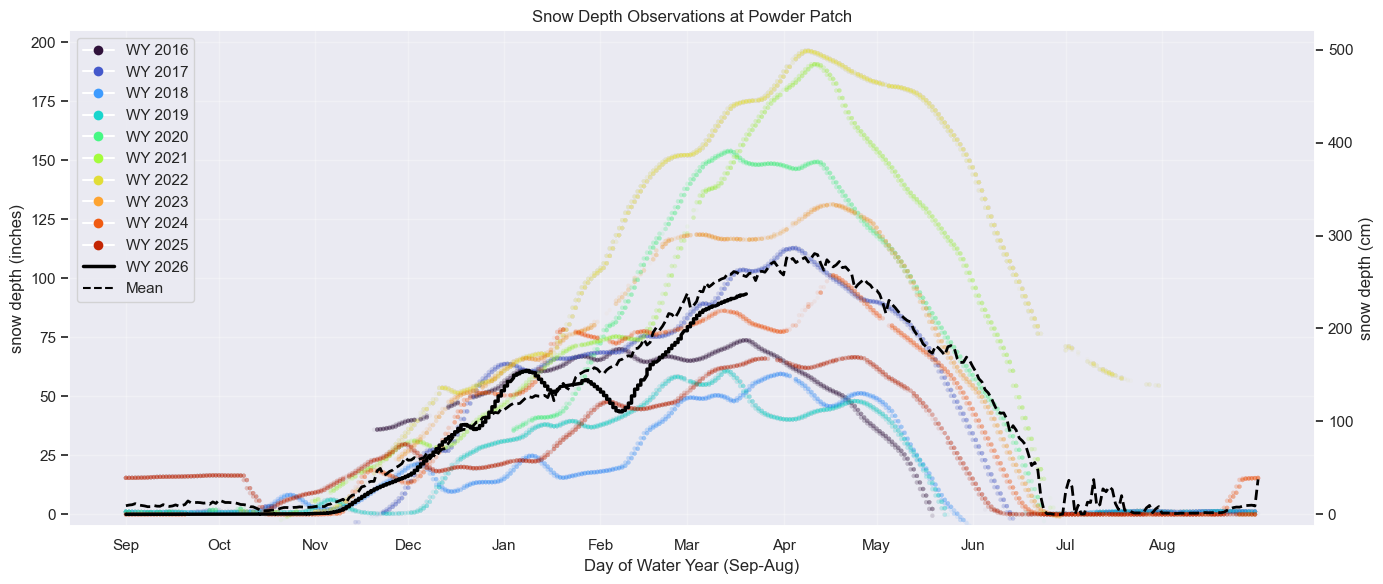

In [27]:
# 2) Explicit highlight year, with all other years on a colorscale
plot_snowdepth_by_wateryear(
    df,
    depth_col='ppsa_smooth_005',
    highlight_wy=2026,
    other_years_style='colorscale',
    cmap_name='turbo',
    other_years_alpha=0.03,
)

## Plot Function #2: Fill Between Min and Max

In [11]:
def plot_snowdepth_with_minmax_envelope(
    df,
    depth_col='ppsa_smooth_002',
    highlight_wy=None,
    figsize=(14, 6),
    title=None,
):
    """
    Plot one highlighted water year plus a min-max envelope.

    Envelope logic: uses all water years from the minimum available WY
    up to and including the highlighted WY.

    The function computes plotting fields internally:
    - wy: water year (Sep-Aug)
    - wy_day: day of water year (Sep 1 = 1)

    Title behavior:
    - If title is provided, use it.
    - If title is None, infer station name from depth_col prefix:
      heen -> Heen Latinee SNOTEL
      ppsa -> Powder Patch
      tram -> Mount Roberts Tram
    """

    if depth_col not in df.columns:
        raise ValueError(f"Missing required column: {depth_col}")

    # Build a default title from the station code in depth_col when not provided.
    if title is None:
        station_code = depth_col.split('_')[0].lower()
        station_title_map = {
            'heen': 'Heen Latinee SNOTEL',
            'ppsa': 'Powder Patch',
            'tram': 'Mount Roberts Tram',
        }
        station_name = station_title_map.get(station_code, station_code.upper())
        title = f'Snow Depth Observations at {station_name}'

    plot_df = df[[depth_col]].copy()
    if 'datetime' in df.columns:
        plot_df['dt'] = pd.to_datetime(df['datetime'])
    else:
        plot_df['dt'] = pd.to_datetime(df.index)

    plot_df = plot_df.dropna(subset=[depth_col, 'dt']).copy()
    if plot_df.empty:
        raise ValueError('No valid rows available for plotting after dropping NaNs.')

    plot_df['wy'] = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year + 1,
        plot_df['dt'].dt.year,
    ).astype(int)

    wy_start_year = np.where(
        plot_df['dt'].dt.month >= 9,
        plot_df['dt'].dt.year,
        plot_df['dt'].dt.year - 1,
    )
    wy_start = pd.to_datetime({'year': wy_start_year, 'month': 9, 'day': 1})
    wy_day = (plot_df['dt'].to_numpy() - wy_start.to_numpy()) / np.timedelta64(1, 'D')
    plot_df['wy_day'] = np.floor(wy_day).astype(int) + 1

    water_years = sorted(plot_df['wy'].unique())
    if not water_years:
        raise ValueError('No water years available to plot.')

    if highlight_wy is None:
        user_input = input(f"Enter a water year to highlight in black {water_years}: ")
        try:
            highlight_wy = int(user_input)
        except ValueError as exc:
            raise ValueError('Water year must be an integer.') from exc

    if highlight_wy not in water_years:
        raise ValueError(f"highlight_wy={highlight_wy} not found. Options: {water_years}")

    envelope_df = plot_df[plot_df['wy'] <= highlight_wy].copy()
    grouped = envelope_df.groupby('wy_day')[depth_col]
    min_by_day = grouped.min().sort_index()
    max_by_day = grouped.max().sort_index()
    mean_by_day = grouped.mean().sort_index()

    fig, ax_in = plt.subplots(figsize=figsize)

    ax_in.fill_between(
        min_by_day.index,
        min_by_day.values,
        max_by_day.values,
        color='lightblue',
        alpha=0.7,
        label=f'min-max range (WY {min(water_years)}-{highlight_wy})',
    )

    ax_in.plot(
        mean_by_day.index,
        mean_by_day.values,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label='mean',
    )

    year_data = plot_df[plot_df['wy'] == highlight_wy]
    ax_in.plot(
        year_data['wy_day'],
        year_data[depth_col],
        color='black',
        linewidth=2.5,
        label=f'WY {highlight_wy}',
    )

    tick_dates = [pd.Timestamp(2001, m, 1) for m in range(9, 13)] + [
        pd.Timestamp(2002, m, 1) for m in range(1, 9)
    ]
    wy0 = pd.Timestamp(2001, 9, 1)
    tick_locs = [(d - wy0).days + 1 for d in tick_dates]
    tick_labels = [d.strftime('%b') for d in tick_dates]

    ax_in.set_xticks(tick_locs)
    ax_in.set_xticklabels(tick_labels)
    ax_in.set_xlabel('Day of Water Year (Sep-Aug)')

    ax_in.set_ylabel('snow depth (inches)')
    ax_in.set_ylim(-5, 205)

    ax_cm = ax_in.twinx()
    inch_to_cm = 2.54
    ymin, ymax = ax_in.get_ylim()
    ax_cm.set_ylim(ymin * inch_to_cm, ymax * inch_to_cm)
    ax_cm.set_ylabel('snow depth (cm)')

    ax_cm.yaxis.set_label_position('right')
    ax_cm.yaxis.tick_right()
    ax_in.yaxis.tick_left()
    ax_in.yaxis.set_label_position('left')
    ax_cm.grid(False)

    ax_in.set_title(title)
    ax_in.grid(True, alpha=0.3)

    legend_elements = [
        Line2D([0], [0], color='lightblue', lw=6, label=f'min-max range (WY {min(water_years)}-{highlight_wy})'),
        Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='mean'),
        Line2D([0], [0], color='black', lw=2.5, label=f'WY {highlight_wy}'),
    ]
    ax_in.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    plt.show()


## Example calls:
## 1) Prompt for highlighted WY
## plot_snowdepth_with_minmax_envelope(df, depth_col='tram_smooth_002')

## 2) Explicit highlight year
## plot_snowdepth_with_minmax_envelope(
##     df,
##     depth_col='tram_smooth_002',
##     highlight_wy=2024,
## )
##
## 3) Override title manually (optional)
## plot_snowdepth_with_minmax_envelope(
##     df,
##     depth_col='heen_smooth_002',
##     highlight_wy=2026,
##     title='Custom Title Here',
## )

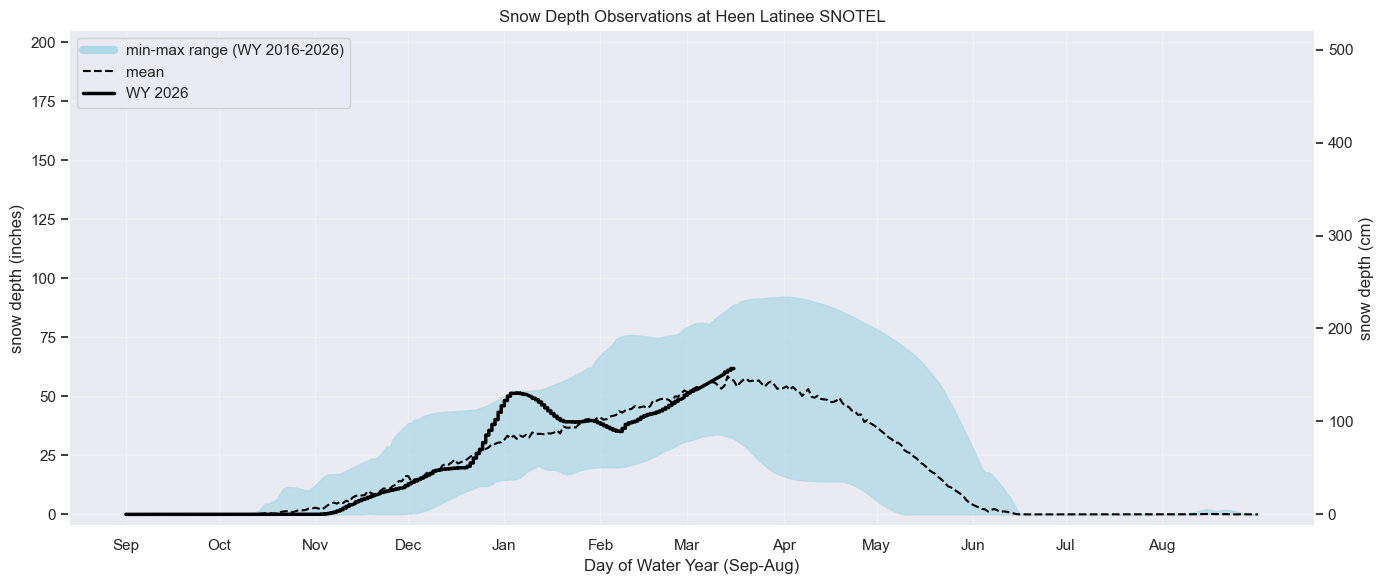

In [12]:
plot_snowdepth_with_minmax_envelope(
    df,
    depth_col='heen_smooth_005',
    highlight_wy=2026,
)

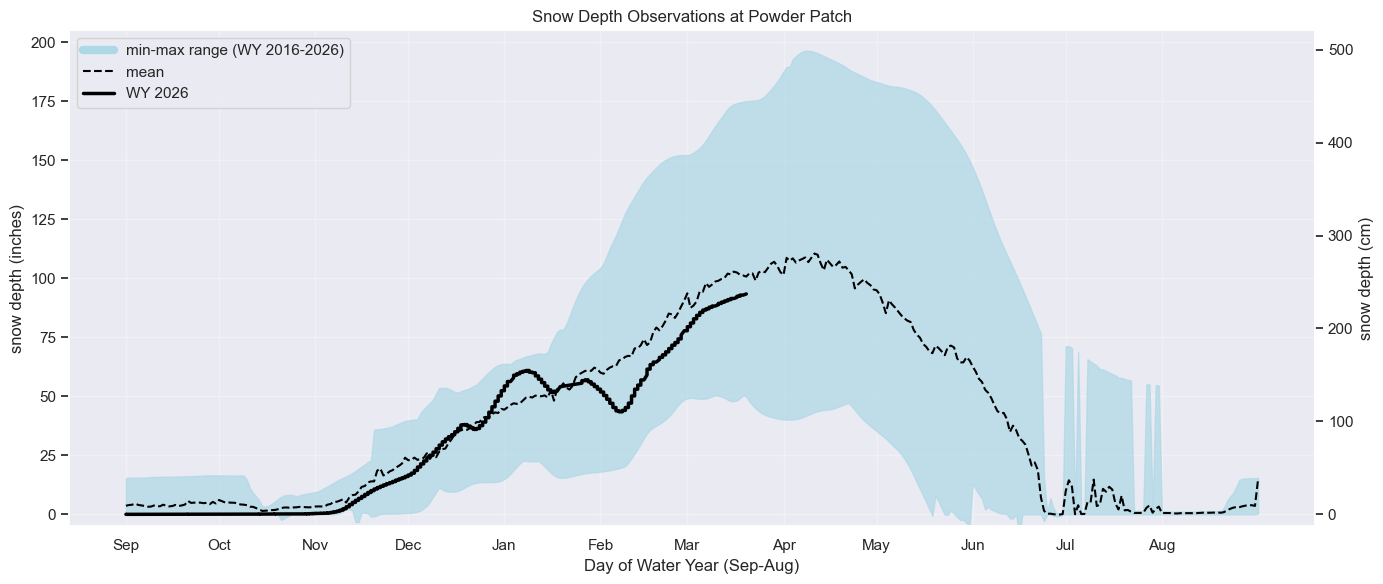

In [13]:
plot_snowdepth_with_minmax_envelope(
    df,
    depth_col='ppsa_smooth_005',
    highlight_wy=2026,
)

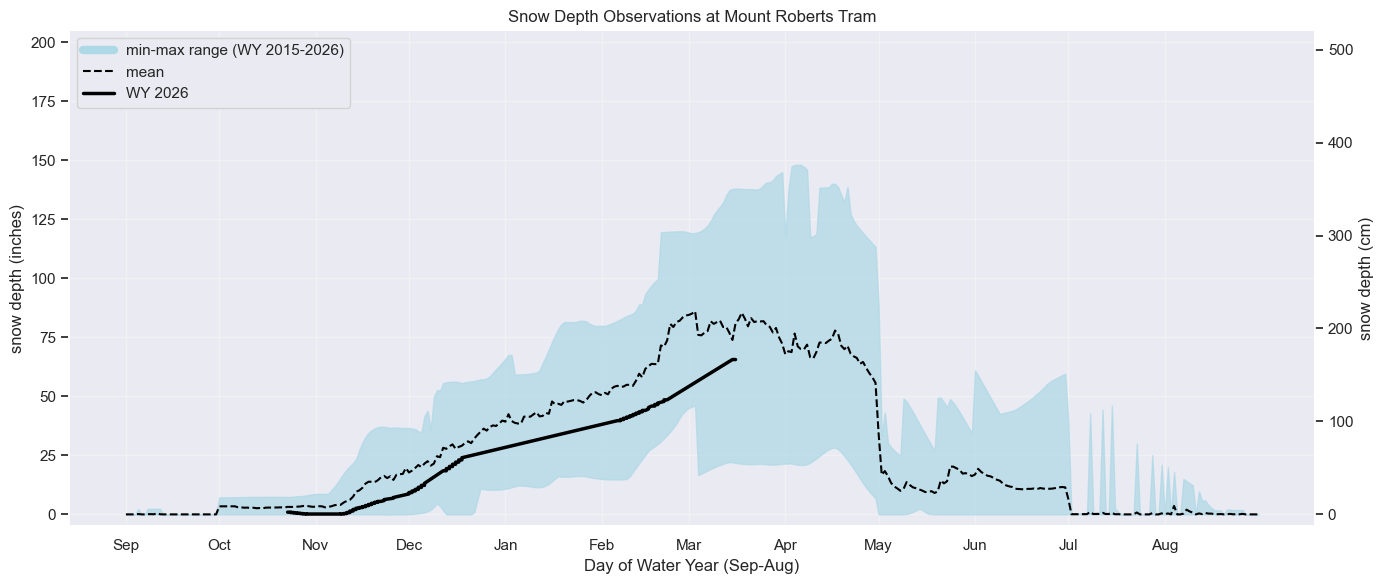

In [14]:
plot_snowdepth_with_minmax_envelope(
    df,
    depth_col='tram_smooth_005',
    highlight_wy=2026,
)